# Notebook 02 — Baseline e Modelo Refinado

**Sistema:** PRF — Classificação de Gravidade de Acidentes  
**Fonte:** https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf  
**Data de acesso:** 2026-06-02  
**Licença:** Dados Abertos do Governo Federal

---

## Estrutura do Notebook

1. Pré-processamento dos dados
2. **Baseline: Regressão Logística** (obrigatório)
3. **Modelo Refinado: Random Forest Classifier**
4. Comparativo de métricas
5. Análise de erros
6. Feature importance

## 1. Setup e Pré-processamento

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

# Raiz do projeto
PROJETO_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJETO_ROOT))

RANDOM_STATE = 42  # seed global — usado em TODOS os modelos
CLASS_NAMES = ['Sem Vítimas', 'Com Vítimas Feridas', 'Com Vítimas Fatais']
LABEL_MAP = {'Sem Vítimas': 0, 'Com Vítimas Feridas': 1, 'Com Vítimas Fatais': 2}

print('Setup concluído.')

Setup concluído.


In [2]:
# Executar pré-processamento
from app.preprocessing import executar_pipeline

PROCESSED_DIR = PROJETO_ROOT / 'data' / 'processed'

if not (PROCESSED_DIR / 'X_train.npy').exists():
    print('Executando pré-processamento...')
    X_train, X_test, y_train, y_test = executar_pipeline()
else:
    print('Arrays já existem. Carregando...')
    X_train = np.load(PROCESSED_DIR / 'X_train.npy')
    X_test  = np.load(PROCESSED_DIR / 'X_test.npy')
    y_train = np.load(PROCESSED_DIR / 'y_train.npy')
    y_test  = np.load(PROCESSED_DIR / 'y_test.npy')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'Distribuição y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Arrays já existem. Carregando...
X_train: (456839, 9) | X_test: (114210, 9)
y_train: (456839,) | y_test: (114210,)
Distribuição y_train: {np.int64(0): np.int64(45089), np.int64(1): np.int64(337085), np.int64(2): np.int64(74665)}


## 2. Baseline — Regressão Logística

**Por que Regressão Logística?**
- Interpretável: os coeficientes revelam o impacto de cada feature
- Treina rapidamente mesmo em datasets grandes (~500k linhas)
- Serve como referência: se o Random Forest não superar, o problema está nos dados
- Dentro de um `Pipeline` com `StandardScaler` para evitar data leakage

In [3]:
print('Treinando Regressão Logística (baseline)...')

pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        solver='lbfgs',
    )),
])

pipeline_logreg.fit(X_train, y_train)
y_pred_logreg = pipeline_logreg.predict(X_test)

print('Treinamento concluído.')

Treinando Regressão Logística (baseline)...
Treinamento concluído.


In [4]:
# Métricas do baseline
acc_base = accuracy_score(y_test, y_pred_logreg)
prec_base = precision_score(y_test, y_pred_logreg, average='macro', zero_division=0)
rec_base = recall_score(y_test, y_pred_logreg, average='macro', zero_division=0)
f1_base = f1_score(y_test, y_pred_logreg, average='macro', zero_division=0)

metricas_baseline = {
    'model': 'LogisticRegression',
    'accuracy': round(float(acc_base), 4),
    'precision_macro': round(float(prec_base), 4),
    'recall_macro': round(float(rec_base), 4),
    'f1_macro': round(float(f1_base), 4),
    'random_state': RANDOM_STATE,
    'data_access_date': '2026-06-02',
}

print('=== Métricas do Baseline (Regressão Logística) ===')
for k, v in metricas_baseline.items():
    print(f'  {k}: {v}')

print(f'\n=== Relatório Completo ===')
print(classification_report(y_test, y_pred_logreg, target_names=CLASS_NAMES, zero_division=0))

=== Métricas do Baseline (Regressão Logística) ===
  model: LogisticRegression
  accuracy: 0.4141
  precision_macro: 0.4002
  recall_macro: 0.4469
  f1_macro: 0.3542
  random_state: 42
  data_access_date: 2026-06-02

=== Relatório Completo ===
                     precision    recall  f1-score   support

        Sem Vítimas       0.12      0.32      0.18     11272
Com Vítimas Feridas       0.82      0.38      0.51     84271
 Com Vítimas Fatais       0.26      0.65      0.37     18667

           accuracy                           0.41    114210
          macro avg       0.40      0.45      0.35    114210
       weighted avg       0.66      0.41      0.46    114210



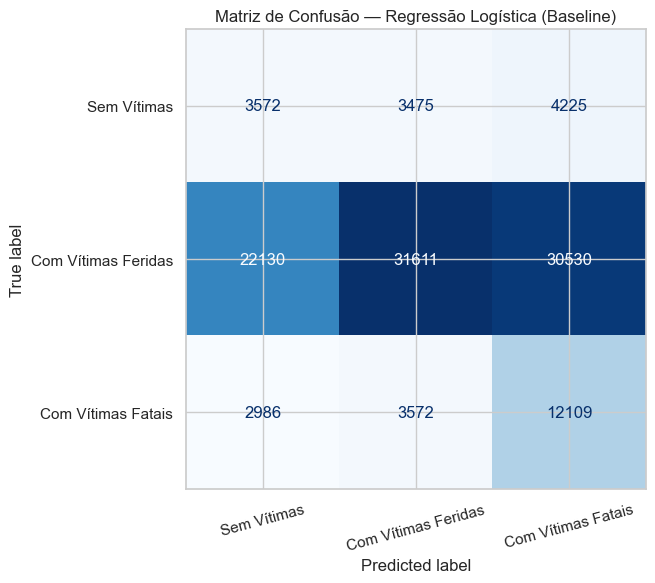

In [5]:
# Matriz de confusão — baseline
fig, ax = plt.subplots(figsize=(8, 6))
cm_base = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão — Regressão Logística (Baseline)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [6]:
# Salvar modelo baseline
MODELS_DIR = PROJETO_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

bundle_logreg = {
    'pipeline': pipeline_logreg,
    'feature_columns': None,
    'classes': CLASS_NAMES,
    'model_type': 'logistic_regression_baseline',
}
joblib.dump(bundle_logreg, MODELS_DIR / 'baseline_logreg.joblib')
print(f'Modelo baseline salvo em {MODELS_DIR / "baseline_logreg.joblib"}')

Modelo baseline salvo em C:\Users\EM09\projeto-ml\models\baseline_logreg.joblib


## 3. Modelo Refinado — Random Forest Classifier

**Por que Random Forest?**
- Não-linear: captura interações entre features
- Robusto a outliers e features em escalas diferentes
- Fornece `feature_importances_` para explicabilidade
- Suporta `class_weight='balanced'` para datasets desbalanceados

In [7]:
print('Treinando Random Forest (n_estimators=100, random_state=42)...')

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Treinamento concluído.')

Treinando Random Forest (n_estimators=100, random_state=42)...
Treinamento concluído.


In [8]:
# Métricas do Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='macro', zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, average='macro', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

print('=== Métricas do Random Forest ===')
print(f'  Accuracy:        {acc_rf:.4f}')
print(f'  Precision Macro: {prec_rf:.4f}')
print(f'  Recall Macro:    {rec_rf:.4f}')
print(f'  F1 Macro:        {f1_rf:.4f}')

print(f'\n=== Relatório Completo ===')
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, zero_division=0))

=== Métricas do Random Forest ===
  Accuracy:        0.9208
  Precision Macro: 0.8516
  Recall Macro:    0.8965
  F1 Macro:        0.8724

=== Relatório Completo ===
                     precision    recall  f1-score   support

        Sem Vítimas       0.73      0.83      0.77     11272
Com Vítimas Feridas       0.97      0.93      0.95     84271
 Com Vítimas Fatais       0.86      0.93      0.89     18667

           accuracy                           0.92    114210
          macro avg       0.85      0.90      0.87    114210
       weighted avg       0.93      0.92      0.92    114210



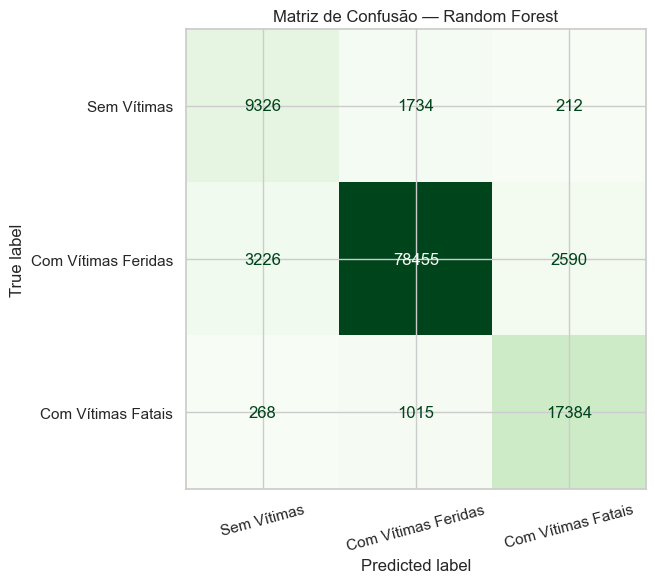

In [9]:
# Matriz de confusão — Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Matriz de Confusão — Random Forest')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Executando validação cruzada 5-fold (F1 Macro)...

Scores por fold: [0.8614, 0.8628, 0.8611, 0.8595, 0.8594]
Média:  0.8608
Desvio: 0.0013


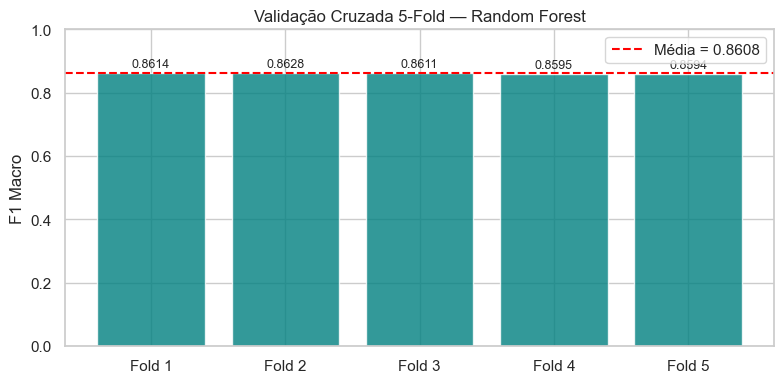

In [10]:
# Validação cruzada 5-fold
print('Executando validação cruzada 5-fold (F1 Macro)...')
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)

print(f'\nScores por fold: {[round(float(s), 4) for s in cv_scores]}')
print(f'Média:  {cv_scores.mean():.4f}')
print(f'Desvio: {cv_scores.std():.4f}')

# Gráfico dos scores de validação cruzada
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars = ax.bar(folds, cv_scores, color='teal', edgecolor='white', alpha=0.8)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Média = {cv_scores.mean():.4f}')
ax.set_ylim(0, 1)
ax.set_ylabel('F1 Macro')
ax.set_title('Validação Cruzada 5-Fold — Random Forest')
ax.legend()
for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Salvar modelo Random Forest
bundle_rf = {
    'pipeline': rf,
    'feature_columns': None,
    'classes': CLASS_NAMES,
    'model_type': 'random_forest',
}
joblib.dump(bundle_rf, MODELS_DIR / 'random_forest.joblib')
print(f'Modelo RF salvo em {MODELS_DIR / "random_forest.joblib"}')

Modelo RF salvo em C:\Users\EM09\projeto-ml\models\random_forest.joblib


## 4. Feature Importance — Top 10 Features

Top features por importância:
               feature  importancia
                    br     0.181078
        causa_acidente     0.164883
           tracado_via     0.160599
         tipo_acidente     0.149259
                    uf     0.143786
condicao_metereologica     0.086503
              fase_dia     0.053433
            tipo_pista     0.034174
              uso_solo     0.026284


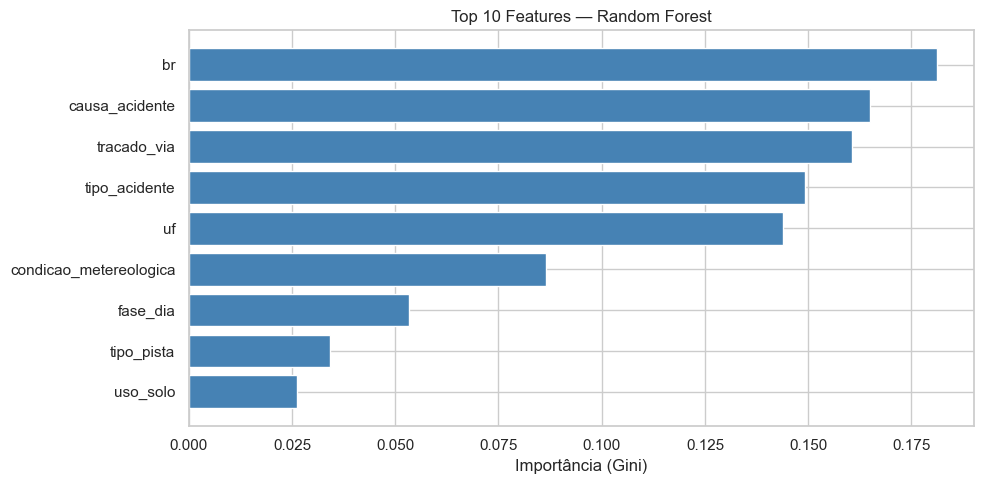

In [12]:
from app.preprocessing import FEATURE_COLUMNS

importancias = rf.feature_importances_
nomes_features = [f for f in FEATURE_COLUMNS if f in [
    'uf', 'causa_acidente', 'tipo_acidente', 'fase_dia',
    'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'br'
]]

# Ajustar se número de features diferir
if len(nomes_features) > len(importancias):
    nomes_features = nomes_features[:len(importancias)]
elif len(nomes_features) < len(importancias):
    nomes_features = nomes_features + [f'feature_{i}' for i in range(len(importancias) - len(nomes_features))]

df_importancias = pd.DataFrame({
    'feature': nomes_features,
    'importancia': importancias
}).sort_values('importancia', ascending=False)

print('Top features por importância:')
print(df_importancias.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
top10 = df_importancias.head(10)
ax.barh(top10['feature'][::-1], top10['importancia'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Importância (Gini)')
ax.set_title('Top 10 Features — Random Forest')
plt.tight_layout()
plt.show()

## 5. Análise de Erros

In [13]:
# Onde o Random Forest mais erra
erros_mask = y_pred_rf != y_test
y_test_erros = y_test[erros_mask]
y_pred_erros = y_pred_rf[erros_mask]

print(f'Total de erros no teste: {erros_mask.sum():,} de {len(y_test):,} ({erros_mask.sum()/len(y_test)*100:.1f}%)')

# Análise dos erros por classe real vs prevista
erros_df = pd.DataFrame({
    'real': [CLASS_NAMES[i] for i in y_test_erros],
    'previsto': [CLASS_NAMES[i] for i in y_pred_erros],
})
print('\nDistribuição dos erros (real → previsto):')
print(erros_df.value_counts().to_string())

Total de erros no teste: 9,045 de 114,210 (7.9%)

Distribuição dos erros (real → previsto):
real                 previsto           
Com Vítimas Feridas  Sem Vítimas            3226
                     Com Vítimas Fatais     2590
Sem Vítimas          Com Vítimas Feridas    1734
Com Vítimas Fatais   Com Vítimas Feridas    1015
                     Sem Vítimas             268
Sem Vítimas          Com Vítimas Fatais      212


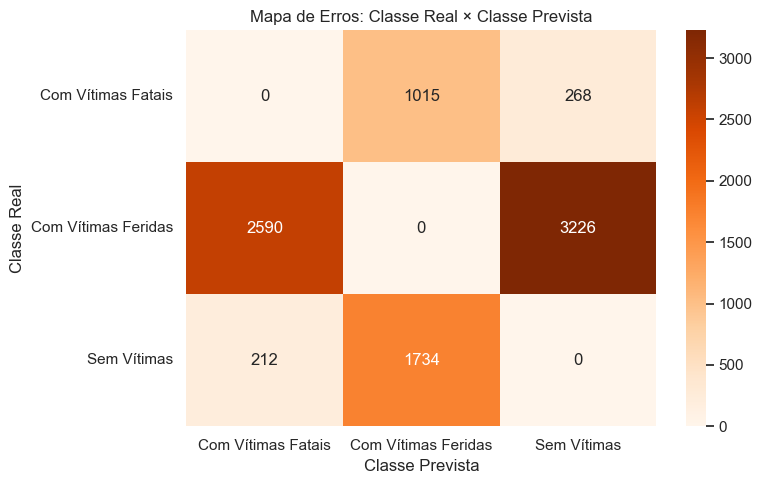


Interpretação: a maior confusão é entre "Com Vítimas Feridas" e as demais classes,
pois ela representa 74% dos dados — modelo tende a prever essa classe com mais frequência.


In [14]:
# Visualização dos erros
pivot_erros = erros_df.groupby(['real', 'previsto']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_erros, annot=True, fmt='d', cmap='Oranges', ax=ax)
ax.set_title('Mapa de Erros: Classe Real × Classe Prevista')
ax.set_xlabel('Classe Prevista')
ax.set_ylabel('Classe Real')
plt.tight_layout()
plt.show()

print('\nInterpretação: a maior confusão é entre "Com Vítimas Feridas" e as demais classes,')
print('pois ela representa 74% dos dados — modelo tende a prever essa classe com mais frequência.')

## 6. Comparativo Baseline vs Refinado

=== COMPARATIVO DE MODELOS ===
                        Modelo  Accuracy  Precision Macro  Recall Macro  F1 Macro
Regressão Logística (Baseline)    0.4141           0.4002        0.4469    0.3542
      Random Forest (Refinado)    0.9208           0.8516        0.8965    0.8724


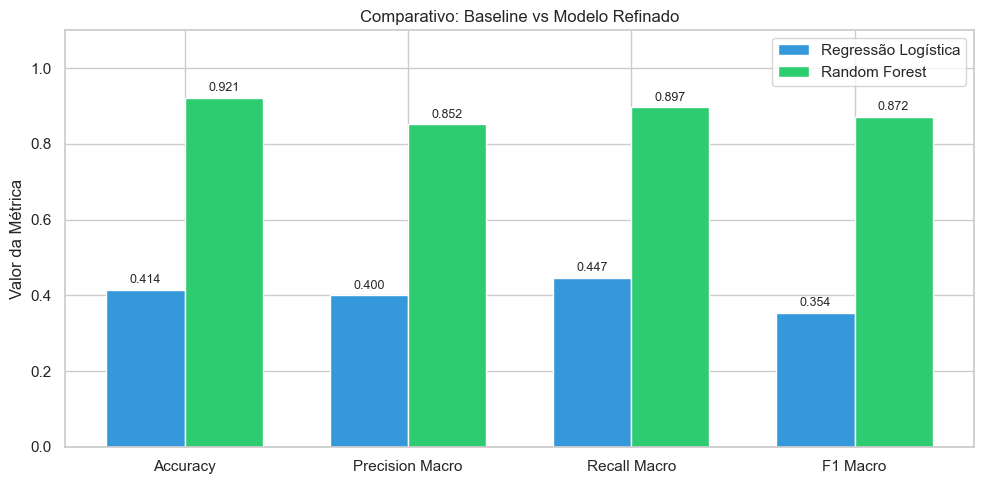

In [15]:
# Tabela comparativa
comparativo = pd.DataFrame({
    'Modelo': ['Regressão Logística (Baseline)', 'Random Forest (Refinado)'],
    'Accuracy': [round(acc_base, 4), round(acc_rf, 4)],
    'Precision Macro': [round(prec_base, 4), round(prec_rf, 4)],
    'Recall Macro': [round(rec_base, 4), round(rec_rf, 4)],
    'F1 Macro': [round(f1_base, 4), round(f1_rf, 4)],
})

print('=== COMPARATIVO DE MODELOS ===')
print(comparativo.to_string(index=False))

# Gráfico comparativo
metricas_nomes = ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro']
valores_base = [acc_base, prec_base, rec_base, f1_base]
valores_rf   = [acc_rf, prec_rf, rec_rf, f1_rf]

x = np.arange(len(metricas_nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, valores_base, width, label='Regressão Logística', color='#3498DB', edgecolor='white')
bars2 = ax.bar(x + width/2, valores_rf, width, label='Random Forest', color='#2ECC71', edgecolor='white')

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metricas_nomes)
ax.set_ylabel('Valor da Métrica')
ax.set_title('Comparativo: Baseline vs Modelo Refinado')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# Salvar metrics.json
metricas_rf = {
    'model': 'RandomForestClassifier',
    'n_estimators': 100,
    'accuracy': round(float(acc_rf), 4),
    'precision_macro': round(float(prec_rf), 4),
    'recall_macro': round(float(rec_rf), 4),
    'f1_macro': round(float(f1_rf), 4),
    'cv_f1_macro_mean': round(float(cv_scores.mean()), 4),
    'cv_f1_macro_std': round(float(cv_scores.std()), 4),
    'cv_scores': [round(float(s), 4) for s in cv_scores],
    'random_state': RANDOM_STATE,
    'data_access_date': '2026-06-02',
}

metrics_json = {
    'baseline_logreg': metricas_baseline,
    'random_forest': metricas_rf,
}

(MODELS_DIR / 'metrics.json').write_text(
    json.dumps(metrics_json, indent=2, ensure_ascii=False)
)
print(f'metrics.json salvo em {MODELS_DIR / "metrics.json"}')
print(json.dumps(metrics_json, indent=2, ensure_ascii=False))

metrics.json salvo em C:\Users\EM09\projeto-ml\models\metrics.json
{
  "baseline_logreg": {
    "model": "LogisticRegression",
    "accuracy": 0.4141,
    "precision_macro": 0.4002,
    "recall_macro": 0.4469,
    "f1_macro": 0.3542,
    "random_state": 42,
    "data_access_date": "2026-06-02"
  },
  "random_forest": {
    "model": "RandomForestClassifier",
    "n_estimators": 100,
    "accuracy": 0.9208,
    "precision_macro": 0.8516,
    "recall_macro": 0.8965,
    "f1_macro": 0.8724,
    "cv_f1_macro_mean": 0.8608,
    "cv_f1_macro_std": 0.0013,
    "cv_scores": [
      0.8614,
      0.8628,
      0.8611,
      0.8595,
      0.8594
    ],
    "random_state": 42,
    "data_access_date": "2026-06-02"
  }
}
